In [66]:
from ultralytics import YOLO

model_path = "../Models/yolov8n.pt"
model = YOLO(model_path)

####Exponential Decay in Weighting Frames

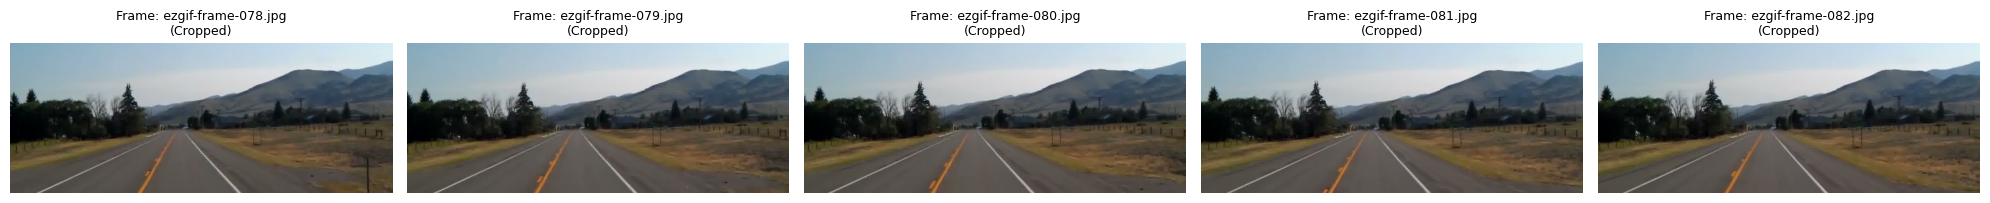

Successfully cleared folder and saved 5 cropped images to: c:\2025-2026 project\SafeSight_Senior\Notebooks\Lane_Departure\Cropped_Output


In [67]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np 
from pathlib import Path
import shutil  # NEW: Imported for folder clearing

base_dir = Path.cwd().parent.parent
data_dir = base_dir / "Data"

train_img_path = data_dir / "ezgif-1889e8046cb70a91-jpg"
# 1. Get all files and sort them to maintain the time sequence
all_images = sorted([
    p for p in os.listdir(train_img_path) 
    if p.endswith(('.jpg', '.png', '.jpeg')) and ".lines" not in p
])

# 2. Select a random starting index for a continuous block of 5
if len(all_images) >= 5:
    start_idx = random.randint(0, len(all_images) - 5)
    test_images = all_images[start_idx : start_idx + 5]
else:
    test_images = all_images
    print(f"Note: Only {len(all_images)} images available.")

# Save the sequence to JSON
with open("test_images.json", "w") as f:
    json.dump(test_images, f)

# --- NEW: Setup and CLEAR YOLO output directory ---
Cropped_Output_dir = Path.cwd() / "Cropped_Output"

# If the folder exists, delete it and all its contents
if Cropped_Output_dir.exists():
    shutil.rmtree(Cropped_Output_dir)

# Recreate the fresh, empty directory
Cropped_Output_dir.mkdir(parents=True, exist_ok=True)
# --------------------------------------------------

# 3. Plotting and Cropping the sequence
plt.figure(figsize=(20, 5))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(train_img_path, img_name)
    image = Image.open(img_path)
    
    # Crop the bottom 30%
    w, h = image.size
    cropped_image = image.crop((0, 0, w, int(h * 0.70)))
    
    # Save the cropped image to the fresh YOLO folder
    save_path = Cropped_Output_dir / img_name
    cropped_image.save(save_path)
    
    # Plotting the *cropped* image 
    plt.subplot(1, 5, i + 1)
    plt.imshow(cropped_image)
    plt.title(f"Frame: {img_name}\n(Cropped)", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Successfully cleared folder and saved {len(test_images)} cropped images to: {Cropped_Output_dir}")

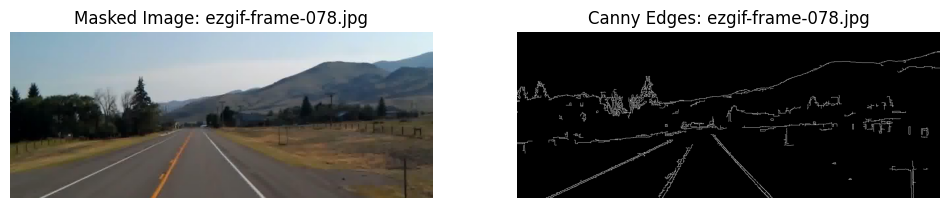

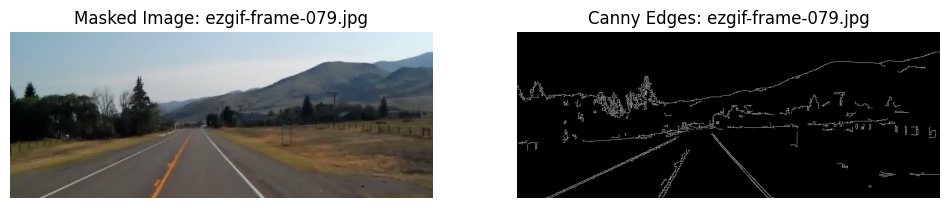

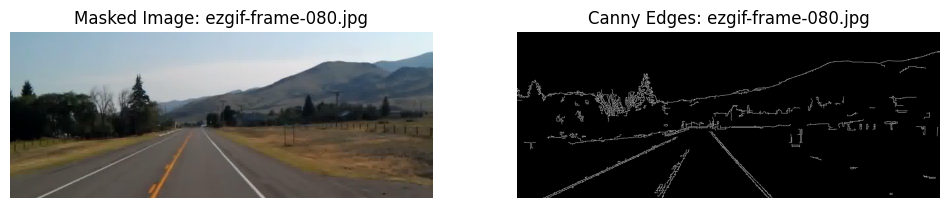

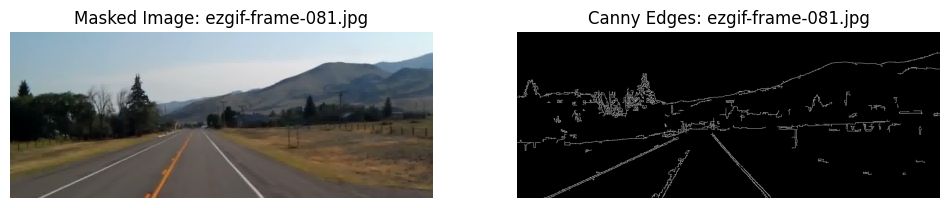

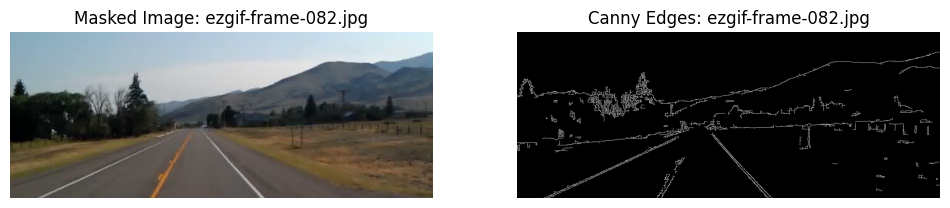

In [68]:
# Output folder
Canny_Edge =  Path.cwd()/ "Canny_Edge_Results"
Canny_Edge.mkdir(exist_ok=True)

# Clear output folder
for p in Canny_Edge.iterdir():
    if p.is_file():
        p.unlink()
for img_file in test_images:
    img_path = os.path.join(Cropped_Output_dir, img_file)
    image = cv2.imread(str(img_path))

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Apply Canny Edge Detector
    # The thresholds 300 (low) and 400 (high) determine edge sensitivity
    edges = cv2.Canny(gray_image, 50, 150)
    cv2.imwrite(os.path.join(Canny_Edge, img_file), edges)
    # 3. Display the original masked image vs the edge detection result
    plt.figure(figsize=(12, 6))

    # Original Masked Image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Masked Image: {img_file}")
    plt.axis('off')

    # Canny Edge Output
    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap='gray')
    plt.title(f"Canny Edges: {img_file}")
    plt.axis('off')

    plt.show()

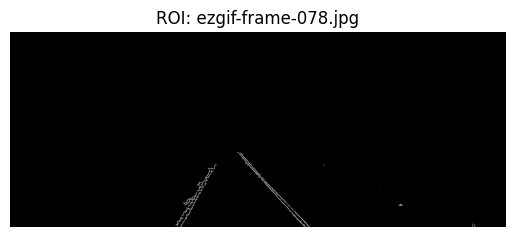

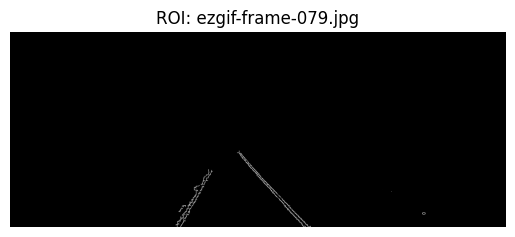

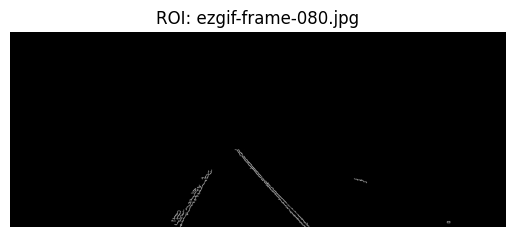

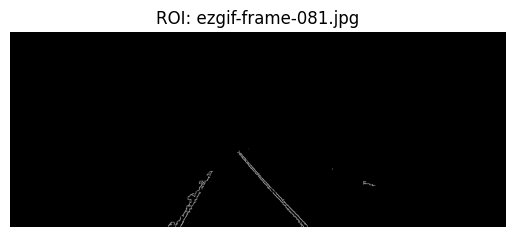

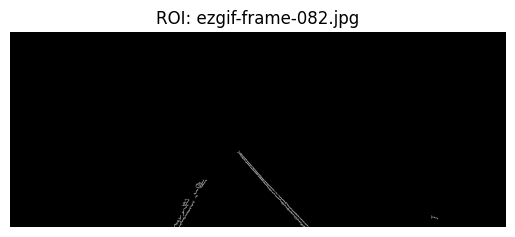

In [69]:
def region_of_interest(image):
    height, width = image.shape[:2]

    # Define polygon 
    polygon = np.array([[
        (int(0.1 * width), height),
        (int(0.45 * width), int(0.6  * height)),
        (int(0.55 * width), int(0.6  * height)),
        (int(0.95 * width), height)
    ]], dtype=np.int32)

    # Create mask
    mask = np.zeros_like(image)

    # Fill polygon with white
    cv2.fillPoly(mask, polygon, (255, 255, 255))

    # Apply mask
    masked_image = cv2.bitwise_and(image, mask)
    return masked_image

# Output folder
Masked_Results =  Path.cwd()/ "Masked_Results"
Masked_Results.mkdir(exist_ok=True)

# Clear output folder
for p in Masked_Results.iterdir():
    if p.is_file():
        p.unlink()
os.makedirs(Masked_Results, exist_ok=True)

Canny_Edge_Results_dir = Path.cwd()/ "Canny_Edge_Results"

test_images = [f for f in os.listdir(Canny_Edge_Results_dir)]
for img_file in test_images:
    img_path = os.path.join(Canny_Edge_Results_dir, img_file)
    image = cv2.imread(img_path)
    roi_image = region_of_interest(image)  # Now passing actual image array
    roi_rgb = cv2.cvtColor(roi_image, cv2.COLOR_BGR2RGB)
    
    cv2.imwrite(os.path.join(Masked_Results, img_file), roi_image)
    plt.imshow(roi_rgb)
    plt.title(f"ROI: {img_file}")
    plt.axis('off')
    plt.show()


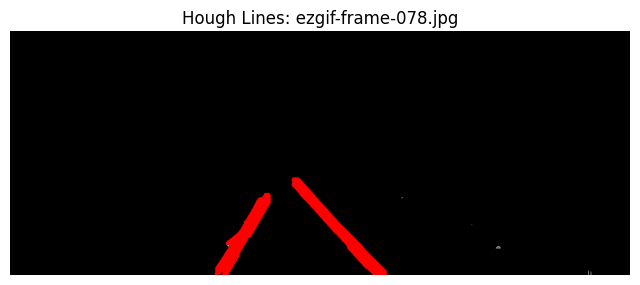

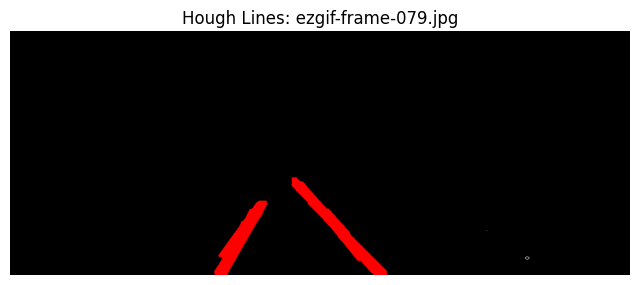

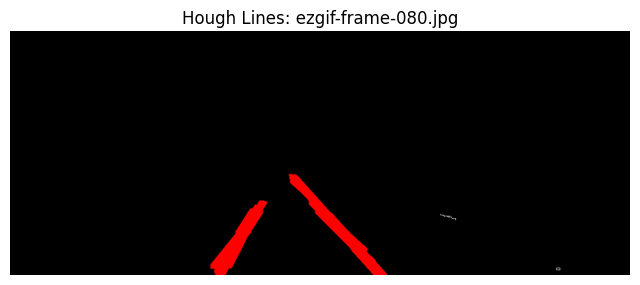

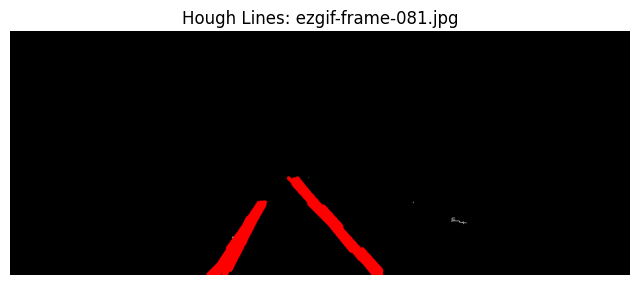

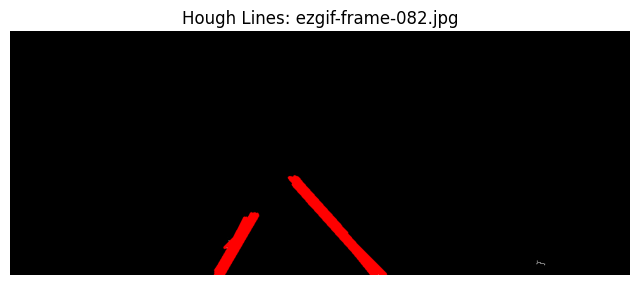

In [70]:
input_folder = "masked_results"
output_folder = "hough_results" 
os.makedirs(output_folder, exist_ok=True)

# parameters for hough transform
rho = 6                
theta = np.pi / 60   
threshold = 160       
min_line_length = 40
max_line_gap = 25        


test_images = [f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

for img_file in test_images:
    img_path = os.path.join(input_folder, img_file)
    
    masked_edges = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if masked_edges is None:
        print(f"Could not read {img_file}. Skipping...")
        continue
        
    #Hough on the edge detected & masked image
    lines = cv2.HoughLinesP(
        masked_edges, 
        rho, 
        theta, 
        threshold, 
        np.array([]), 
        minLineLength=min_line_length, 
        maxLineGap=max_line_gap
    )
    color_edges = cv2.cvtColor(masked_edges, cv2.COLOR_GRAY2RGB)
    
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                # Draw red markings for the lanes 
                cv2.line(color_edges, (x1, y1), (x2, y2), [255, 0, 0], 5)

    save_path = os.path.join(output_folder, img_file)
    cv2.imwrite(save_path, cv2.cvtColor(color_edges, cv2.COLOR_RGB2BGR))

    # 3. Display the result inline
    plt.figure(figsize=(8, 5))
    plt.imshow(color_edges)
    plt.title(f"Hough Lines: {img_file}")
    plt.axis('off')
    plt.show()

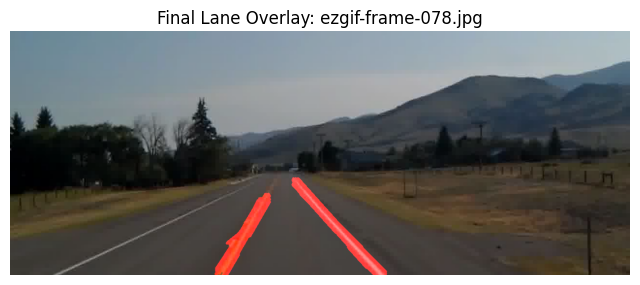

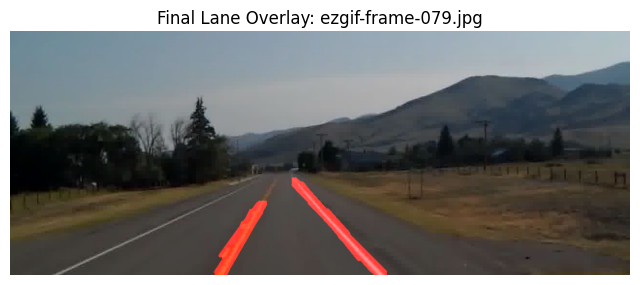

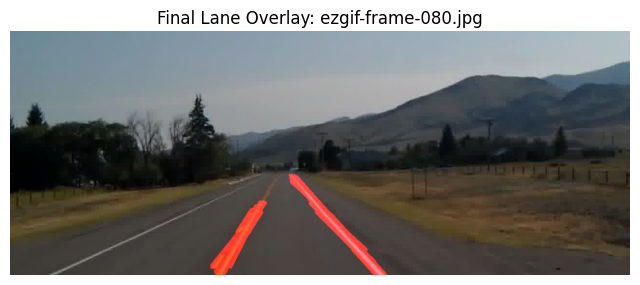

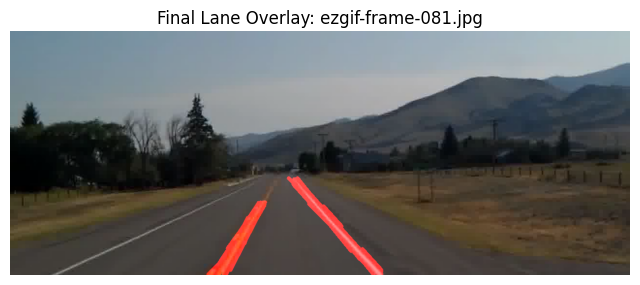

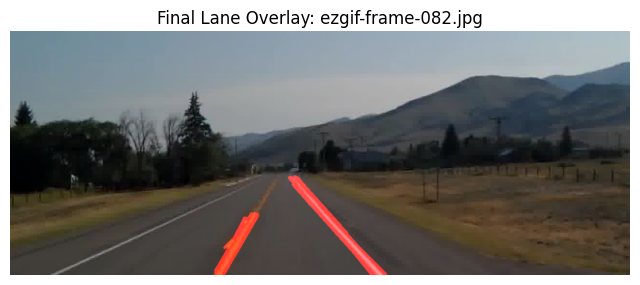

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define your directories
masked_dir =  Path.cwd() / "Masked_Results"       
output_dir = "final_lane_results"     
os.makedirs(output_dir, exist_ok=True)

# Hough Transform Hyperparameters
rho = 6                
theta = np.pi / 60   
threshold = 160       
min_line_length = 40
max_line_gap = 25        

# Get all images in the masked folder
image_files = [f for f in os.listdir(masked_dir)]

for img_file in image_files:
    masked_path = os.path.join(masked_dir, img_file)
    orig_path = os.path.join(Cropped_Output_dir, img_file) # Assumes filenames match exactly
    
    # Read the pre-processed edge mask (grayscale)
    masked_edges = cv2.imread(masked_path, cv2.IMREAD_GRAYSCALE)
    # Read the original undistorted image (color)
    orig_img = cv2.imread(orig_path)
    
    # Check if both images exist before proceeding
    if masked_edges is None:
        print(f"Could not read mask for {img_file}. Skipping...")
        continue
    if orig_img is None:
        print(f"Could not read original image for {img_file}. Skipping...")
        continue
        
    # 1. Calculate Hough lines using the masked image
    lines = cv2.HoughLinesP(
        masked_edges, 
        rho, 
        theta, 
        threshold, 
        np.array([]), 
        minLineLength=min_line_length, 
        maxLineGap=max_line_gap
    )

    # 2. Draw the lines onto a blank image the same size as the original
    line_img = np.zeros_like(orig_img)
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                # Draw thick red lines (BGR format for OpenCV)
                cv2.line(line_img, (x1, y1), (x2, y2), [0, 0, 255], 5)

    # 3. Blend the line image with the original image
    # cv2.addWeighted gives the lines a slightly transparent "overlay" look
    final_img = cv2.addWeighted(orig_img, 0.8, line_img, 1.0, 0.0)

    # 4. Save the result
    save_path = os.path.join(output_dir, img_file)
    cv2.imwrite(save_path, final_img)

    # 5. Display the result inline (Convert BGR to RGB for matplotlib)
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Final Lane Overlay: {img_file}")
    plt.axis('off')
    plt.show()

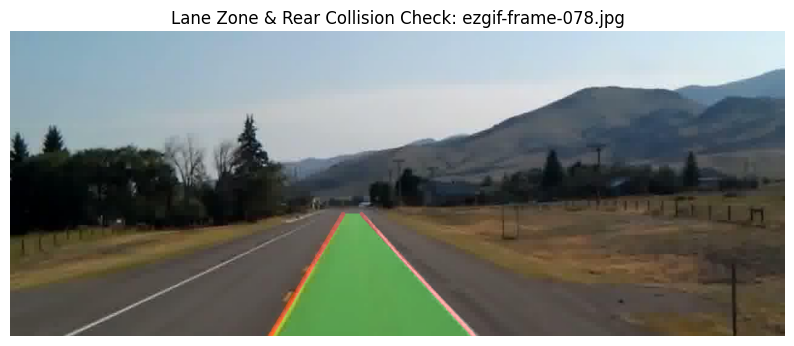

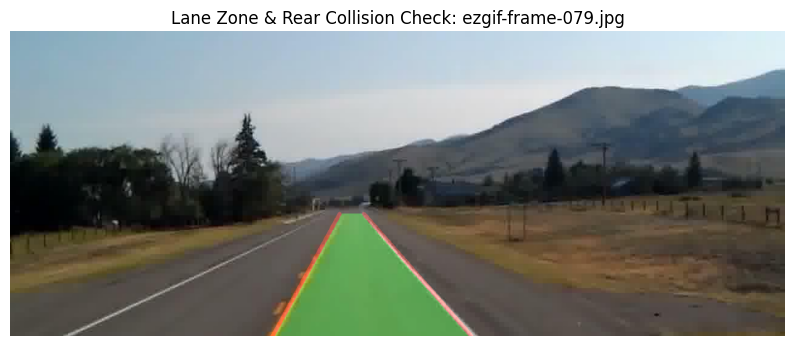

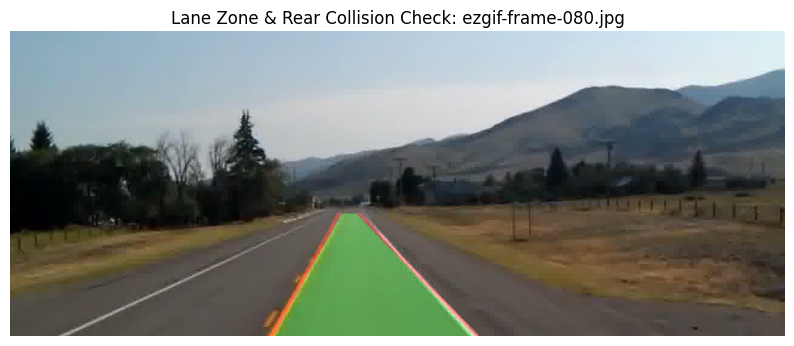

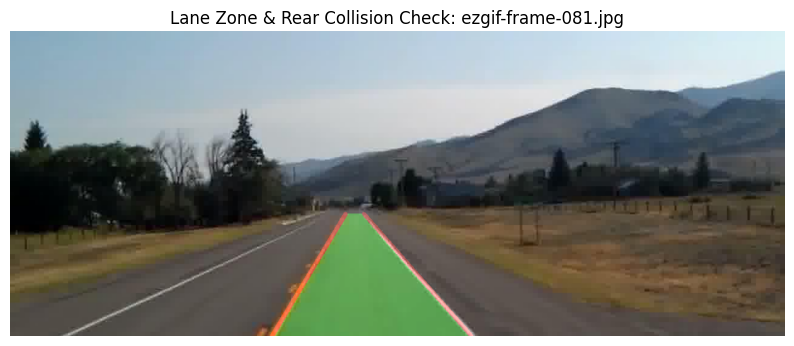

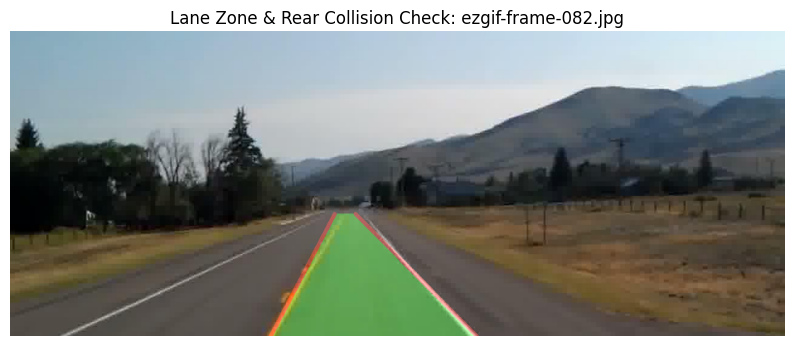

In [73]:


# Distance Estimation Constants
REAL_CAR_WIDTH = 2.0  # Assumed vehicle width in meters
FOCAL_LENGTH = 1000    # Tunable focal length in pixels
        
output_dir = "lane_zone_results"      
os.makedirs(output_dir, exist_ok=True)

# Hough Parameters
rho = 1                  
theta = np.pi / 180      
threshold = 30           
min_line_length = 40     
max_line_gap = 20        

def average_slope_intercept(image, lines, horizon_y):
    """
    Separates the line segments by their slope (left vs right) 
    and averages them to create two solid boundary lines.
    """
    left_fit = []
    right_fit = []
    
    if lines is None:
        return None, None
        
    for line in lines:
        for x1, y1, x2, y2 in line:
            if x1 == x2: 
                continue 
                
            parameters = np.polyfit((x1, x2), (y1, y2), 1)
            slope = parameters[0]
            intercept = parameters[1]
            
            if slope < -0.3:
                left_fit.append((slope, intercept))
            elif slope > 0.3:
                right_fit.append((slope, intercept))
                
    y_bottom = image.shape[0]  
    y_top = horizon_y          
    
    left_line = None
    right_line = None
    
    if len(left_fit) > 0:
        left_fit_average = np.average(left_fit, axis=0)
        slope, intercept = left_fit_average
        x1 = int((y_bottom - intercept) / slope)
        x2 = int((y_top - intercept) / slope)
        left_line = (x1, y_bottom, x2, y_top)
        
    if len(right_fit) > 0:
        right_fit_average = np.average(right_fit, axis=0)
        slope, intercept = right_fit_average
        x1 = int((y_bottom - intercept) / slope)
        x2 = int((y_top - intercept) / slope)
        right_line = (x1, y_bottom, x2, y_top)
        
    return left_line, right_line

# ---------------------------------------------------------
# 2. MAIN PROCESSING LOOP
# ---------------------------------------------------------
image_files = [f for f in os.listdir(masked_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

for img_file in image_files:
    masked_path = os.path.join(masked_dir, img_file)
    orig_path = os.path.join(Cropped_Output_dir, img_file) 
    
    masked_edges = cv2.imread(masked_path, cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.imread(orig_path)
    
    if masked_edges is None or orig_img is None:
        continue
        
    # --- A. LANE DETECTION ---
    lines = cv2.HoughLinesP(
        masked_edges, rho, theta, threshold, np.array([]), 
        minLineLength=min_line_length, maxLineGap=max_line_gap
    )

    horizon_y = int(orig_img.shape[0] * 0.6) 
    left_line, right_line = average_slope_intercept(orig_img, lines, horizon_y)

    overlay = np.zeros_like(orig_img)
    polygon_points = None

    if left_line is not None and right_line is not None:
        x1_l, y1_l, x2_l, y2_l = left_line
        x1_r, y1_r, x2_r, y2_r = right_line
        
        polygon_points = np.array([[
            (x1_l, y1_l), 
            (x2_l, y2_l), 
            (x2_r, y2_r), 
            (x1_r, y1_r)
        ]], dtype=np.int32)
        
        cv2.fillPoly(overlay, polygon_points, [0, 255, 0])
        cv2.line(overlay, (x1_l, y1_l), (x2_l, y2_l), [0, 0, 255], 5)
        cv2.line(overlay, (x1_r, y1_r), (x2_r, y2_r), [0, 0, 255], 5)

    alpha = 0.3 
    final_img = cv2.addWeighted(overlay, alpha, orig_img, 1.0, 0.0)

    # --- B. YOLO VEHICLE DETECTION & DISTANCE ---
    # Convert BGR to RGB for YOLO
    rgb_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    results = model(rgb_img, verbose=False)
    
    for box in results[0].boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        cls_name = model.names[cls_id]
        
        # Only process vehicles with a decent confidence
        if cls_name in ['car', 'truck', 'bus'] and conf > 0.3:
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            
            # Find where the vehicle touches the ground
            bottom_center_x = (x1 + x2) // 2
            bottom_center_y = y2
            
            is_in_lane = False
            
            # Check if the bottom center point is inside our lane polygon
            if polygon_points is not None:
                # pointPolygonTest returns > 0 if inside, 0 if on the edge, < 0 if outside
                dist_to_poly = cv2.pointPolygonTest(polygon_points[0], (bottom_center_x, bottom_center_y), measureDist=False)
                if dist_to_poly >= 0:
                    is_in_lane = True
            
            if is_in_lane:
                # Calculate Distance
                pixel_width = x2 - x1
                distance = (REAL_CAR_WIDTH * FOCAL_LENGTH) / pixel_width
                
                # Draw Blue Bounding Box for vehicles IN the lane
                cv2.rectangle(final_img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                
                # Draw a dot at the bottom center to visualize the collision check point
                cv2.circle(final_img, (bottom_center_x, bottom_center_y), 6, (0, 255, 255), -1)
                
                # Overlay Class and Distance
                label = f"{cls_name} {distance:.1f}m"
                cv2.putText(final_img, label, (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            else:
                # Optional: Draw Gray bounding box for vehicles NOT in our lane
                cv2.rectangle(final_img, (x1, y1), (x2, y2), (150, 150, 150), 1)

    # --- C. SAVE AND DISPLAY ---
    save_path = os.path.join(output_dir, img_file)
    cv2.imwrite(save_path, final_img)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Lane Zone & Rear Collision Check: {img_file}")
    plt.axis('off')
    plt.show()

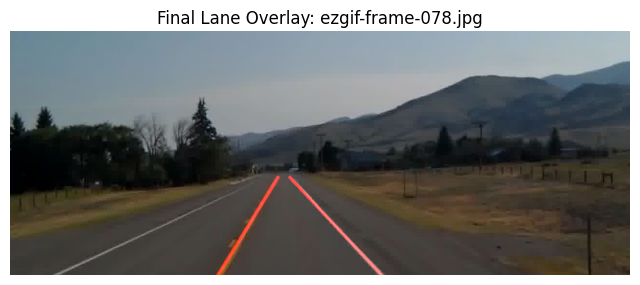

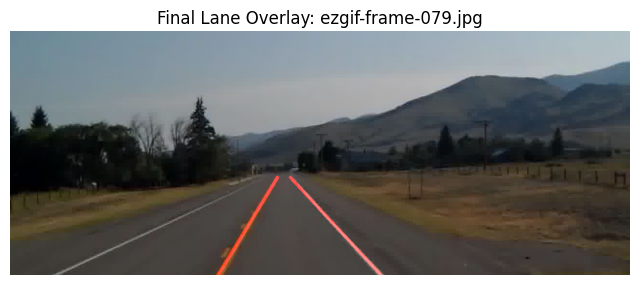

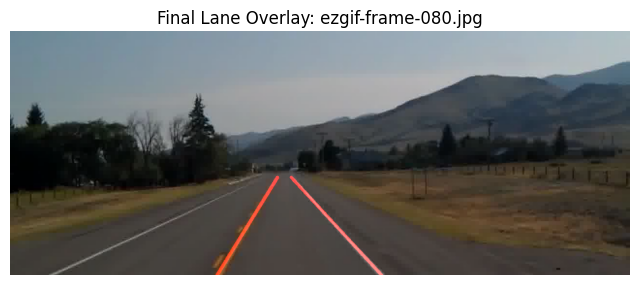

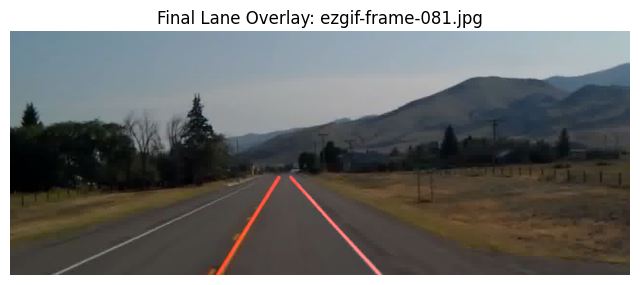

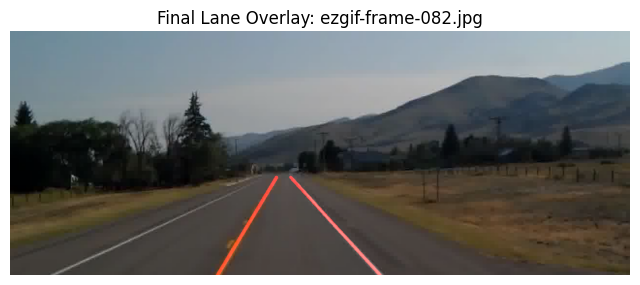

In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

#Average line segments into one left and one right line
def average_slope_intercept(lines):
    left_lines = []
    left_weights = []
    right_lines = []
    right_weights = []
    if lines is None:
        return None
    for line in lines:
        for x1, y1, x2, y2 in line:
            if x1 == x2: continue
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1
            length = np.sqrt((y2-y1)**2 + (x2-x1)**2)
            if slope < -0.3:
                left_lines.append((slope, intercept))
                left_weights.append(length)
            elif slope > 0.3:
                right_lines.append((slope, intercept))
                right_weights.append(length)
    left_lane = np.average(left_lines, axis=0, weights=left_weights) if len(left_weights) > 0 else None
    right_lane = np.average(right_lines, axis=0, weights=right_weights) if len(right_weights) > 0 else None
    return left_lane, right_lane

#Convert slope and intercept back to coordinates for drawing
def make_line_points(y1, y2, line):
    if line is None: 
        return None
    slope, intercept = line
    if slope == 0: 
        return None
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return ((x1, int(y1)), (x2, int(y2)))

#Define directories
masked_dir = Path.cwd() / "Masked_Results"       
output_dir = "final_lane_results"     
os.makedirs(output_dir, exist_ok=True)

#Hough transform hyperparameters
rho = 6                
theta = np.pi / 60   
threshold = 160       
min_line_length = 40
max_line_gap = 25        

#Get sorted image files to ensure sequential processing
image_files = sorted([f for f in os.listdir(masked_dir)])

#Initialize ema variables
alpha = 0.5
smoothed_left = None
smoothed_right = None

#Process frames
for img_file in image_files:
    masked_path = os.path.join(masked_dir, img_file)
    orig_path = os.path.join(Cropped_Output_dir, img_file)
    masked_edges = cv2.imread(masked_path, cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.imread(orig_path)
    if masked_edges is None or orig_img is None:
        continue
        
    #Calculate hough lines
    lines = cv2.HoughLinesP(
        masked_edges, rho, theta, threshold, np.array([]), 
        minLineLength=min_line_length, maxLineGap=max_line_gap
    )

    #Extract averaged left and right lanes
    lanes = average_slope_intercept(lines)
    
    #Update ema for left lane
    if lanes and lanes[0] is not None:
        if smoothed_left is None:
            smoothed_left = np.array(lanes[0])
        else:
            smoothed_left = (alpha * np.array(lanes[0])) + ((1 - alpha) * smoothed_left)
            
    #Update ema for right lane
    if lanes and lanes[1] is not None:
        if smoothed_right is None:
            smoothed_right = np.array(lanes[1])
        else:
            smoothed_right = (alpha * np.array(lanes[1])) + ((1 - alpha) * smoothed_right)

    #Create blank image for drawing lines
    line_img = np.zeros_like(orig_img)
    y_bottom = orig_img.shape[0]
    y_top = int(y_bottom * 0.6) 

    #Draw smoothed left line
    if smoothed_left is not None:
        pts = make_line_points(y_bottom, y_top, smoothed_left)
        if pts: cv2.line(line_img, pts[0], pts[1], [0, 0, 255], 5)
        
    #Draw smoothed right line
    if smoothed_right is not None:
        pts = make_line_points(y_bottom, y_top, smoothed_right)
        if pts: cv2.line(line_img, pts[0], pts[1], [0, 0, 255], 5)

    #Blend images and save
    final_img = cv2.addWeighted(orig_img, 0.8, line_img, 1.0, 0.0)
    save_path = os.path.join(output_dir, img_file)
    cv2.imwrite(save_path, final_img)

    #Display inline
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Final Lane Overlay: {img_file}")
    plt.axis('off')
    plt.show()